# Stream fitting

### Dimitra Giantsidi & Nolan Ottele 2026

This code measures the length and average width of a detected stream of a galaxy at different angles. It requires the matched-filter detection and the Segment outputs of the galaxy. It also calculates the length-to-width ratio vs. declination of observation. "Object of interest" refers to the stream throughout the code.

In [1]:
# import all necessary libraries
from pathlib import Path as path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re
import math
import os
import copy
import matplotlib as mpl
from scipy.optimize import curve_fit

In [2]:
# enter the name of the galaxy, its matched-filter depth, distance and resolution, and desired number of angles
box = 'rogue'
gal_num = '5'
galaxy_name = f'{box}_{gal_num}'
depth=26
distance=2000
numpix=8000
numangles=24

In [3]:
# define the necessary file paths to get the data from
sd_outputs_path = (f'../substructure_detection/sd_outputs')
segmented_path = path(f'{sd_outputs_path}/Segment/{galaxy_name}/segmented')
centers_path = path(f'{sd_outputs_path}/twod_exp_fit/{galaxy_name}/centers.txt')
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{depth}_{distance}/{galaxy_name}/')

In [4]:
# define necessary values to be updated
area_of_interest = np.zeros((numangles, 89, 89), dtype=bool) # hardcoded for the number of angles
min_obj = 0
max_obj = 0
my_extent = [-60,60,-60,60]

In [5]:
def centers(file_name, galaxy_name):
    """ Identifies the center of the galaxy at a specific angle.
    
    Requires the 2D exponential fit algorithm to have run first and for the existence of the centers path with the centers file
    formatted exactly as defined in the 2D exponential fit algorithm. It reads the declination and azimuth of the file_name, finds
    their match in the file and their respective x- and y- coordinates.
    
    Args:
        file_name (f string):
            The name of the file of the galaxy of interest of which the first two instances of numbers 
            should be the declination and the azimuth of observation in this order (separation by period is acceptable).
        galaxy_name (f string):
            The name of the galaxy of interest.

    Returns:
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
    """
    
    x_center = 0
    y_center = 0
    numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', file_name)]
    angles = numbers[1:-1]
    d = angles[0]
    a = angles[1]
    target_message = 'center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}'
    
    with open(f'{centers_path}', 'r') as file:
        for line in file:
            if target_message in line: # assumes there is only one instance of the correct message
                parts = line.strip().split(':')
                coords = parts[1].split(',')
                x_center = float(coords[0].strip())
                y_center = float(coords[1].strip())
                
    return x_center, y_center

In [6]:
def area_of_interest_finder(image_data):
    """ Identifies and isolates the largest area of a galaxy by its Segment output.

        This function automatically updates the predefined areas_of_interest array with the identifier value of the current stream.

    Args:
        image_data (hdul.data):
            The extracted data of a Segmented galaxy (from a .fits format).

    Returns:
        image_data (hdul.data):
            The modified image data to only include the background and the area of interest
        interest_obj (float):
            The (meaningless) value assigned by Segment to the objects of interest.
        
    """
    
    # identify the largest object
    objects, counts = np.unique(image_data, return_counts=True)
    
    # ... excluding background
    not_bg_mask = objects != 0
    objects = objects[not_bg_mask]
    counts = counts[not_bg_mask]
    
    i_max = np.argmax(counts)

    # remove all objects except the largest
    non_largest_mask = image_data != objects[i_max]
    image_data[non_largest_mask] = 0
    interest_obj = objects[i_max]

    # to mask the area of the matched filter
    area_of_interest[current_rotation, :, :] = image_data == interest_obj

    return image_data, interest_obj

In [7]:
def radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest):
    """ Calculates the density-weighted average radius of the area of interest within each given bin.

    Args:
        n_of_interest (int):
            Number of pixels of interest.
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_of_interest (empty array):
            To be filled with the x-coordinates of the pixels of interest.
        y_of_interest (empty array):
            To be filled with the y-coordinates of the pixels of interest.

    Returns:
        avg_radii (array of floats):
            Array of length equal to n_bins containing the average radius of the object of interest within each bin.
        bin_size (float):
            The size of each bin.
    """
    
    x_delta = [n - x_center for n in x_of_interest]
    y_delta = [n - y_center for n in y_of_interest]

    theta = [0] * n_of_interest

    for i in range(len(x_delta)):
        theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

    bin_size = 2*np.pi/n_bins

    ang_bin = [0] * n_of_interest
    for i in range(len(theta)):
        ang_bin[i] = int(np.floor(theta[i]/bin_size))

    radii = [0] * n_of_interest
    for i in range(n_of_interest):
        radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

    avg_radii = [0] * n_bins

    for j in range(n_bins):
        radii_sum = 0
        radii_counter = 0
        for i in range(len(ang_bin)):
            if ang_bin[i] == j:
                radii_sum = radii_sum + radii[i]
                radii_counter = radii_counter + 1
        if radii_counter == 0:
            radii_average = 0
        else:
            radii_average = radii_sum / radii_counter
        avg_radii[j] = radii_average
    avg_radii = np.array(avg_radii)

    return avg_radii, bin_size

In [8]:
current_rotation = 0

# isolate the area of interest, split it into angular bins and calculate its density-weighted average radius within each bin
for file in sorted(segmented_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]

        # load the segmented fits file
        hdul = fits.open(f'{segmented_path}/{file.name}')
        image_data = hdul[3].data # 3 is the index of isolated objects

        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)

        # plot the bins (only for visual aid purposes)
        n_bins = 32
        
        # find area of interest
        image_data, interest_obj = area_of_interest_finder(image_data)

        x_of_interest = []
        y_of_interest = []

        # find data of interest (non-background and of largest object)
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if val == interest_obj:
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)

        # number of pixels of interest
        n_of_interest = len(x_of_interest)

        # calculate the average readius of each bin
        avg_radii = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        current_rotation = current_rotation + 1

In [9]:
def find_large_outliers(data, multiplier=1.5):
    """ Finds only large, extreme upper outliers while ignoring small values.

    Args:
        data (array of numbers):
            The desired data to be checked for large outliers.

    Returns:
        outlier_values (number or array of numbers):
            The numbers identified as large outliers.
    """
    data = np.array(data)
    
    # Calculate upper quartile parameters
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Establish a high upper fence
    upper_bound = q3 + (multiplier * iqr)
    
    # Extract only values exceeding this high threshold
    outlier_indices = np.where(data > upper_bound)
    outlier_values = data[outlier_indices]
    
    return outlier_values

In [10]:
def ray_cells_in_grid(x0, y0, dx, dy, width, height):
    """Amanatides-Woo traversal algorithm. Copied from the internet. Calculates the grid pixels a line goes through.
    Basic idea is to calculate parametrically which edge of the box a line is approaching at any given time.

    Args:
        x0 (int):
            Starting x value in grid coordinates
        y0 (int):
            Starting y value in grid coordinates
        dx (int):
            Change in x with respect to time. Really just numerator of slope.
        dy (int): 
            Change in y with respect to time. Really just denominator of slope.
        width (int):
            X size of the grid.
        height (int):
            Y size of the grid

    Returns:
        cells (2D array of ints):
            A list of cells the line goes through, including the first cell it starts in.     
    """
    if dx == 0 and dy == 0:
        raise ValueError("direction vector (dx, dy) cannot be (0, 0)")
 
    i, j = math.floor(x0), math.floor(y0)
    if not (0 <= i < width and 0 <= j < height):
        return []
    cells = [(x0,y0),(i, j)]
 
    step_i = 1 if dx > 0 else (-1 if dx < 0 else 0)
    step_j = 1 if dy > 0 else (-1 if dy < 0 else 0)
 
    # tMaxX/tMaxY: parametric distance to the next vertical/horizontal
    # grid line. tDeltaX/tDeltaY: how much that increases per cell.
    if dx != 0:
        next_x = i + (1 if dx > 0 else 0)
        tMaxX = (next_x - x0) / dx
        tDeltaX = abs(1.0 / dx)
    else:
        tMaxX = math.inf
        tDeltaX = math.inf
 
    if dy != 0:
        next_y = j + (1 if dy > 0 else 0)
        tMaxY = (next_y - y0) / dy
        tDeltaY = abs(1.0 / dy)
    else:
        tMaxY = math.inf
        tDeltaY = math.inf
 
    while True:
        if tMaxX < tMaxY:
            tMaxX += tDeltaX
            i += step_i
        elif tMaxY < tMaxX:
            tMaxY += tDeltaY
            j += step_j
        else:
            tMaxX += tDeltaX
            tMaxY += tDeltaY
            i += step_i
            j += step_j
 
        if not (0 <= i < width and 0 <= j < height):
            break
        cells.append((i, j))
        if len(cells)>=11:
            break
 
    return cells

In [11]:
def length_calc(n_bins, x_center, y_center, x_ang, y_ang):
    """ Calculates the total length of the stream.

    Args:
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        total_dist (float):
            The total calculated length of the stream.
    """

    total_dist = 0
    
    for i in range(n_bins):
        
        # calculate the separation between a pair of points
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
        
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
            total_dist = total_dist + dist  # total accumulated distance

            plt.plot([x_ang[p1], x_ang[p2]], [y_ang[p1], y_ang[p2]], color = '#72BCD4', alpha=0.5) # line from point 1 to point 2

    return total_dist

In [12]:
def width_calc(image_data, n_bins, x_ang, y_ang):
    """ Calculates the width of bins of the stream.

    Args:
        image_data (hdul.data):
            The extracted data of a matched-filtered galaxy (from a .fits format).
        n_bins (int):
            Number of bins.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        stream_width_counter (int):
            The number of widths calculated.
        stream_width_total (float):
            The sum of the widths calculated.
    """

    stream_width = 0
    stream_width_counter = 0
    stream_width_total = 0

    for i in range(n_bins):
    
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
    
        x_mid = (x_ang[p1]+x_ang[p2])/2
        y_mid = (y_ang[p1]+y_ang[p2])/2
        #plt.scatter(x_mid, y_mid, color = 'green', s=20) # plots midpoints between any two given points
    
        x_mid_as_grid = round((60+x_mid)*89/120) # converts midpoints into grid coordinates
        y_mid_as_grid = 89-round((60+y_mid)*89/120)
    
        # calculate the separation between a pair of points
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
    
        if x_sep == 0 and y_sep == 0: 
            print(f"{i}. Invalid. No separation.") # prevents crashing in case of non-existing average radius/radii
            
        else:
            cells_1 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, y_sep, x_sep, 89, 89) # lists all cells in line in one direction from muidpoing
            cells_2 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, -y_sep, -x_sep, 89, 89) # lists all cells in opposite direction
    
            emtpy_limit = 5 # limit for consecutive empty encounters. WE STRONGLY ADVISE TO ADJUST FOR EACH GALAXY
            far_limit = 11 # limit for parts of the stream being too close to each other
            
            # identify stopping points due to empty encounters in both directions
            limit_1 = 0
            for n in range(far_limit):
                if (image_data[cells_1[n][1]][cells_1[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_1):
                            if (image_data[cells_1[n+m-1][1]][cells_1[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_1 = n
                    if break_counter == emtpy_limit:
                        break
                limit_1 = n
    
            limit_2 = 0
            for n in range(far_limit):
                if (image_data[cells_2[n][1]][cells_2[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_2):
                            if (image_data[cells_2[n+m-1][1]][cells_2[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_2 = n
                    if break_counter == emtpy_limit:
                        break
                limit_2 = n
    
            # apply stopping points in both directions
            cells_1_culled = [[x, y] for x, y in cells_1[:limit_1] if not ((image_data[y][x]) == 0)]
            cells_2_culled = [[x, y] for x, y in cells_2[:limit_2] if not ((image_data[y][x]) == 0)]
    
            if len(cells_1_culled)!=0 and len(cells_2_culled)!=0: # case where the area extends in both directions
                
                cell_first = cells_1_culled[-1] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)==0 and len(cells_2_culled)!=0: # case where the area does not extend in one direction
    
                cell_first = cells_2_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordinates of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)!=0 and len(cells_2_culled)==0: # case where the area does not extend in the other direction
    
                cell_first = cells_1_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_1_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
                
            else: # case where the area does not extend in either direction
                 print(f"{i}. Invalid. No width.")

    return stream_width_counter, stream_width_total

In [13]:
# define necessary values to be updated
ratio = 0
length_array = []
width_array = []
ratio_array = []

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.382911825767897
13 Width: 13.55039409589333. Distance: 3.8851969479359236
14 Width: 10.870459885346364. Distance: 3.5529933418038593
15 Width: 12.209508051421237. Distance: 3.565785523158849
16 Width: 10.870459885346362. Distance: 3.640093685705103
17 Width: 6.029846231460107. Distance: 3.69669088147585
18 Width: 0.0. Distance: 3.362265710803796
19 Width: 6.02984623146011. Distance: 2.6298483952837155
20 Width: 10.78651685393259. Distance: 4.597538977274204
21 Width: 5.5592435401586515. Distance: 6.0504581247467275
22 Width: 4.263745159777586. Distance: 5.089787683308901
23 Width: 7.260896369170119. Distance: 3.

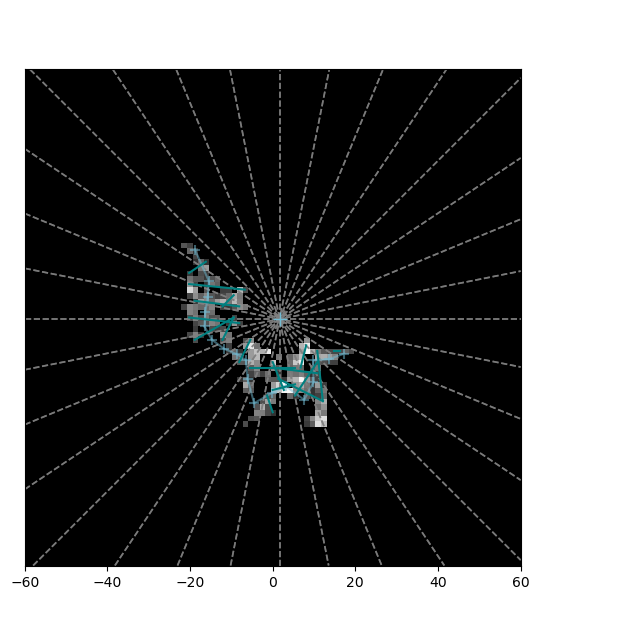

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.42068328030068
13 Width: 13.55039409589333. Distance: 3.8403176072985086
14 Width: 10.870459885346364. Distance: 3.505007636517124
15 Width: 12.209508051421237. Distance: 3.5158948403078805
16 Width: 10.870459885346362. Distance: 3.5923444665403697
17 Width: 6.029846231460107. Distance: 3.649860949996441
18 Width: 0.0. Distance: 3.3124169344430423
19 Width: 6.02984623146011. Distance: 2.5817671418744093
20 Width: 10.78651685393259. Distance: 4.382642921823328
21 Width: 11.520005049866343. Distance: 4.969693791130211
22 Width: 4.263745159777586. Distance: 4.059984885452347
23 Width: 4.861417450063813. Distance: 3

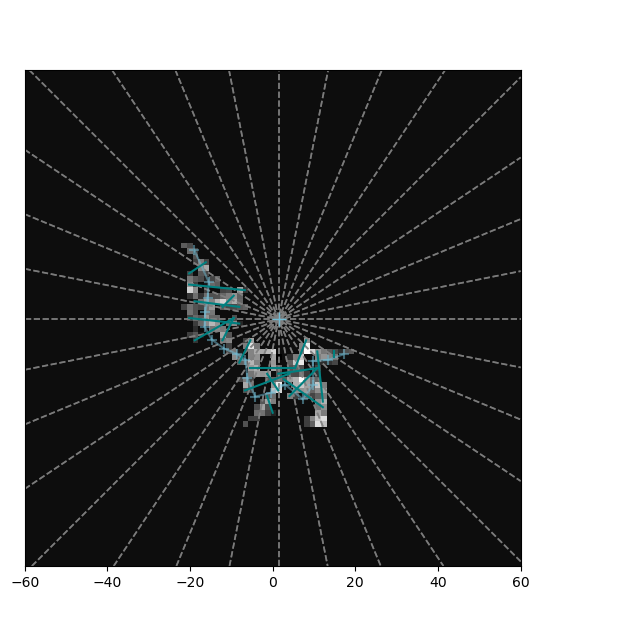

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.455883544271204
13 Width: 13.55039409589333. Distance: 3.9700292463479663
14 Width: 8.527490319555177. Distance: 3.603776036613882
15 Width: 9.534024015998398. Distance: 3.610833929213869
16 Width: 12.43084645927131. Distance: 3.4848121309633386
17 Width: 6.029846231460107. Distance: 4.042145539644332
18 Width: 0.0. Distance: 3.4282306562146854
19 Width: 5.720414409599032. Distance: 2.658615093286009
20 Width: 7.260896369170119. Distance: 3.5991419643542617
21 Width: 11.520005049866343. Distance: 5.159057815924972
22 Width: 4.0449438202247165. Distance: 4.011815422605624
23 Width: 7.861957611027375. Distance: 3.

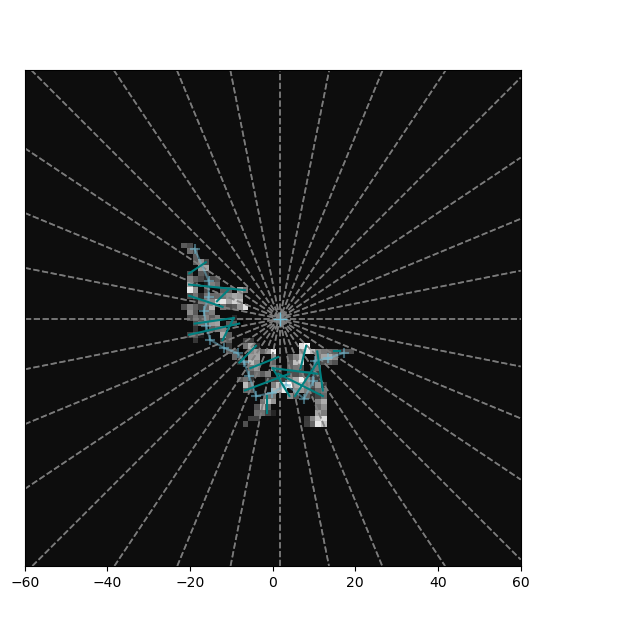

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.368022791891448
13 Width: 12.209508051421237. Distance: 3.847977147377976
14 Width: 10.870459885346364. Distance: 3.511534366624698
15 Width: 12.209508051421237. Distance: 3.5262407022328737
16 Width: 10.870459885346362. Distance: 3.599920556623234
17 Width: 6.029846231460107. Distance: 3.654334062158049
18 Width: 0.0. Distance: 3.3210910211788898
19 Width: 6.02984623146011. Distance: 2.6017042982957626
20 Width: 10.78651685393259. Distance: 4.401386097374549
21 Width: 11.520005049866343. Distance: 4.986119830507663
22 Width: 4.263745159777586. Distance: 4.082910071053322
23 Width: 6.029846231460113. Distance: 3

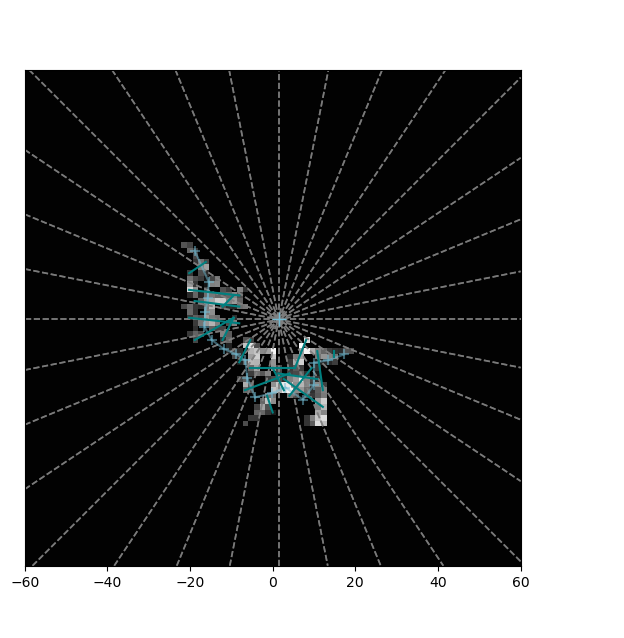

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.4338774906111
13 Width: 13.55039409589333. Distance: 3.8381277891786336
14 Width: 12.209508051421237. Distance: 3.5420542264525863
15 Width: 9.534024015998398. Distance: 3.477999074073427
16 Width: 12.43084645927131. Distance: 3.45223784370807
17 Width: 6.029846231460107. Distance: 4.001052042678633
18 Width: 0.0. Distance: 3.333636984151222
19 Width: 6.02984623146011. Distance: 2.5919335208784706
20 Width: 10.78651685393259. Distance: 4.363965181538426
21 Width: 11.520005049866343. Distance: 5.535480916564928
22 Width: 4.263745159777586. Distance: 4.485213568559706
23 Width: 7.260896369170119. Distance: 3.62343

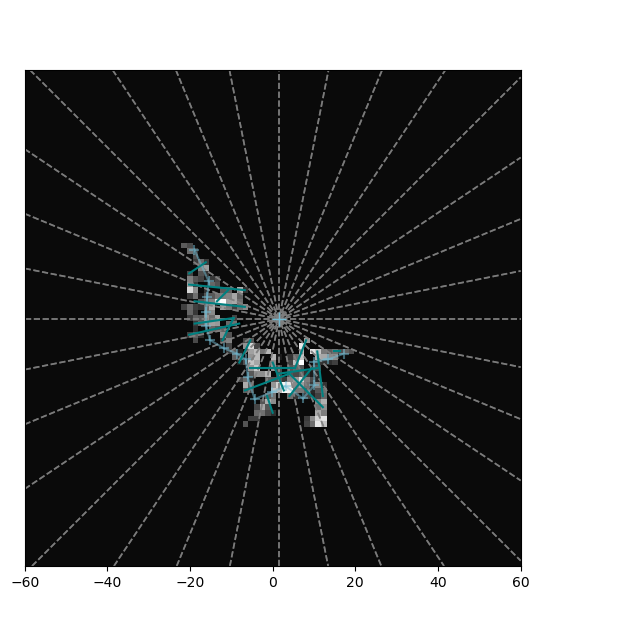

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.436857490988904
13 Width: 13.55039409589333. Distance: 3.891548730529848
14 Width: 10.870459885346364. Distance: 3.565699015883581
15 Width: 9.534024015998398. Distance: 3.5411141267199477
16 Width: 12.43084645927131. Distance: 3.4927093393962387
17 Width: 6.029846231460107. Distance: 4.038499936978368
18 Width: 0.0. Distance: 3.2958656098714196
19 Width: 6.02984623146011. Distance: 2.691622142076164
20 Width: 9.534024015998396. Distance: 4.247681175439822
21 Width: 12.430846459271315. Distance: 5.783743342921007
22 Width: 4.263745159777586. Distance: 4.474290516626435
23 Width: 3.8136096063993565. Distance: 4.0

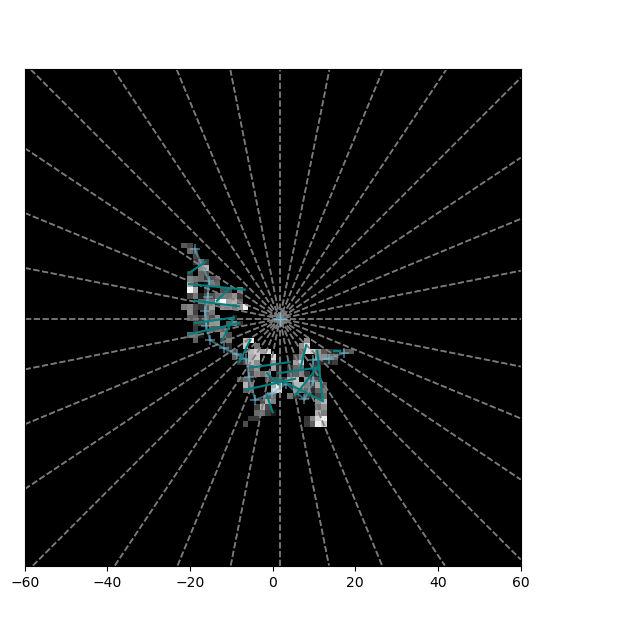

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.411122766398515
13 Width: 12.209508051421237. Distance: 3.8191491996186424
14 Width: 10.870459885346364. Distance: 3.4826594888580926
15 Width: 12.209508051421237. Distance: 3.4952266087542183
16 Width: 10.870459885346362. Distance: 3.571037958611332
17 Width: 6.029846231460107. Distance: 3.626938357925895
18 Width: 0.0. Distance: 3.2905391784617937
19 Width: 5.720414409599032. Distance: 2.556207703137427
20 Width: 9.534024015998396. Distance: 3.9656335192001384
21 Width: 11.520005049866343. Distance: 5.470448625277421
22 Width: 4.263745159777586. Distance: 4.2397342107774145
23 Width: 4.861417450063813. Distanc

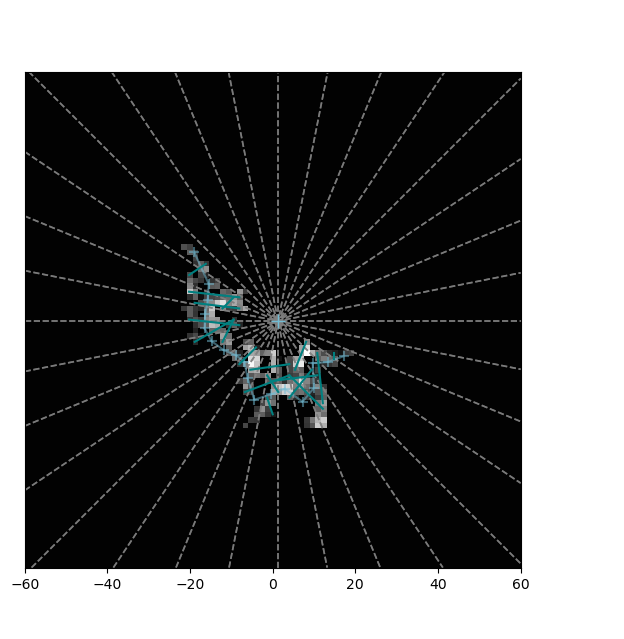

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.435215597343925
13 Width: 13.55039409589333. Distance: 3.9322336292808364
14 Width: 8.527490319555177. Distance: 3.5687710306685156
15 Width: 9.534024015998398. Distance: 3.5741875140674106
16 Width: 12.43084645927131. Distance: 3.4538912638059753
17 Width: 6.029846231460107. Distance: 4.003275124252041
18 Width: 0.0. Distance: 3.335587043467459
19 Width: 6.02984623146011. Distance: 2.592792620979723
20 Width: 10.78651685393259. Distance: 4.362093215695833
21 Width: 11.520005049866343. Distance: 4.945525160931681
22 Width: 4.263745159777586. Distance: 4.059475471220855
23 Width: 7.260896369170119. Distance: 3.66

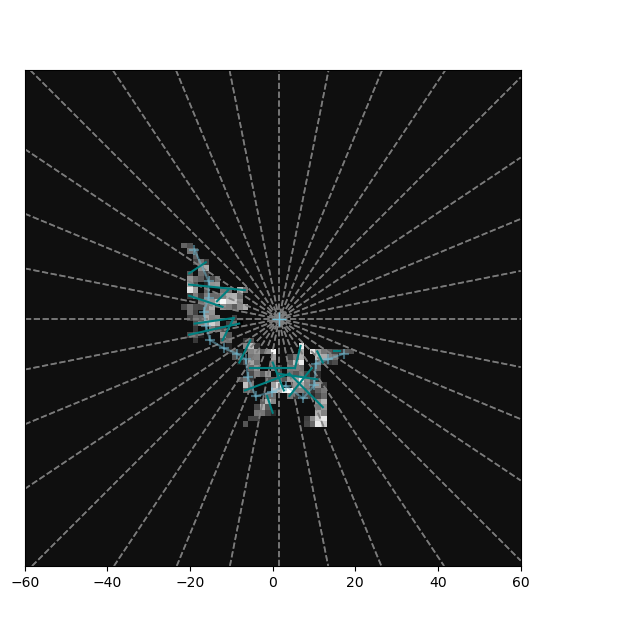

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.368170625500687
13 Width: 12.209508051421237. Distance: 3.8404317938632726
14 Width: 10.870459885346364. Distance: 3.4999717917684787
15 Width: 12.209508051421237. Distance: 3.5135677935518883
16 Width: 10.870459885346362. Distance: 3.5877844995145494
17 Width: 6.029846231460107. Distance: 3.642397902915964
18 Width: 0.0. Distance: 3.3083826113617962
19 Width: 5.720414409599032. Distance: 2.577023565644986
20 Width: 9.534024015998396. Distance: 3.9726958556149468
21 Width: 12.430846459271315. Distance: 5.739287780258144
22 Width: 4.263745159777586. Distance: 4.6188974691300855
23 Width: 9.815878502400702. Distan

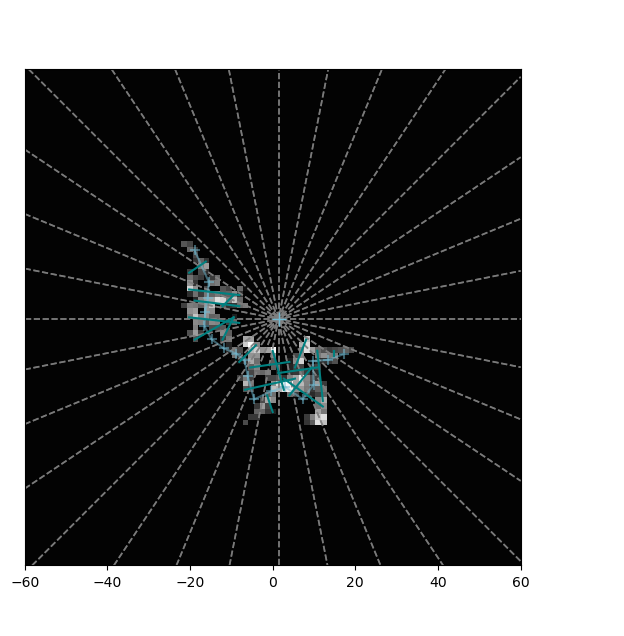

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.219423957183646
13 Width: 6.875082490237464. Distance: 3.96506112685621
14 Width: 8.527490319555177. Distance: 3.5059232421685564
15 Width: 9.534024015998398. Distance: 3.5075688902568958
16 Width: 10.870459885346362. Distance: 3.5531336255623303
17 Width: 6.029846231460107. Distance: 3.611137827868903
18 Width: 0.0. Distance: 3.2712350431503436
19 Width: 6.02984623146011. Distance: 2.5305986195538326
20 Width: 9.534024015998398. Distance: 3.950506493484482
21 Width: 11.520005049866343. Distance: 5.222728940205603
22 Width: 4.263745159777586. Distance: 4.052066232811519
23 Width: 9.8158785024007. Distance: 3.5017

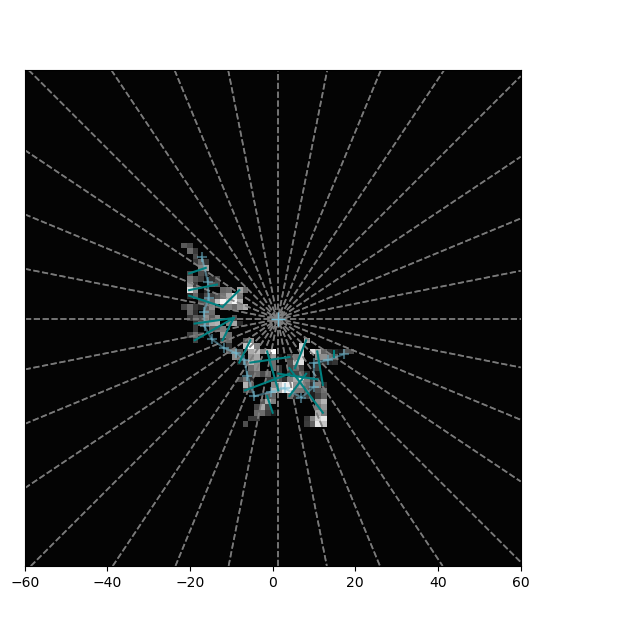

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.438792487460978
13 Width: 13.55039409589333. Distance: 3.88351193430202
14 Width: 6.029846231460107. Distance: 3.715644486223522
15 Width: 5.55924354015865. Distance: 3.7707459656347124
16 Width: 12.43084645927131. Distance: 3.4767040290893654
17 Width: 6.029846231460107. Distance: 4.025451540515108
18 Width: 0.0. Distance: 3.414227059257613
19 Width: 6.02984623146011. Distance: 2.580835559630589
20 Width: 10.78651685393259. Distance: 4.586802783546716
21 Width: 9.044769347190167. Distance: 4.387206794915875
22 Width: 4.0449438202247165. Distance: 3.7520723324527143
23 Width: 3.8136096063993565. Distance: 4.0543

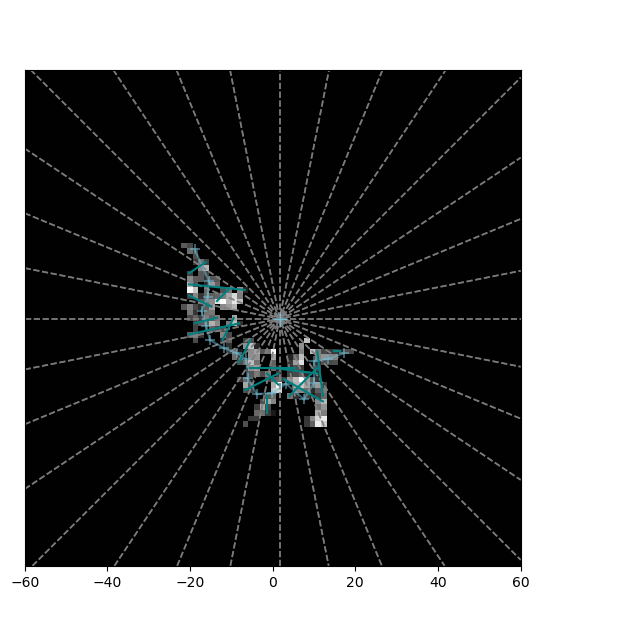

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.408180237179998
13 Width: 12.209508051421237. Distance: 3.804212676242145
14 Width: 10.870459885346364. Distance: 3.463209695567425
15 Width: 12.209508051421237. Distance: 3.475264434627251
16 Width: 10.870459885346362. Distance: 3.5513902399964707
17 Width: 6.029846231460107. Distance: 3.606895879393803
18 Width: 0.0. Distance: 3.27003131880776
19 Width: 6.02984623146011. Distance: 2.5406736274969566
20 Width: 9.534024015998396. Distance: 3.9668143324085605
21 Width: 11.520005049866343. Distance: 5.237941851916713
22 Width: 4.263745159777586. Distance: 4.065188445445247
23 Width: 4.861417450063813. Distance: 3.

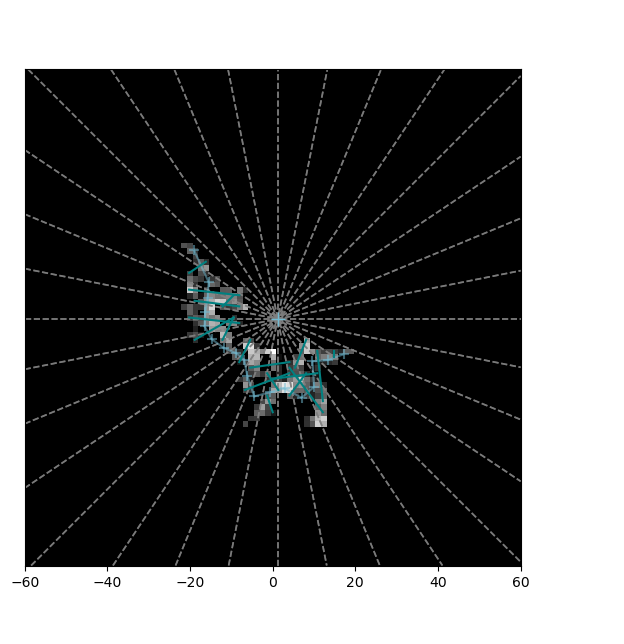

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 5.840503129822657
13 Width: 6.875082490237464. Distance: 4.098445170372269
14 Width: 9.815878502400697. Distance: 3.506974120800279
15 Width: 9.534024015998398. Distance: 3.511509000410006
16 Width: 10.870459885346362. Distance: 3.556920474788901
17 Width: 6.029846231460107. Distance: 3.614521130399953
18 Width: 0.0. Distance: 3.2753109295525498
19 Width: 6.02984623146011. Distance: 2.5358170137933107
20 Width: 9.534024015998398. Distance: 3.9527779651958546
21 Width: 11.520005049866343. Distance: 5.22351104152464
22 Width: 4.263745159777586. Distance: 4.056866712011184
23 Width: 9.8158785024007. Distance: 3.506015

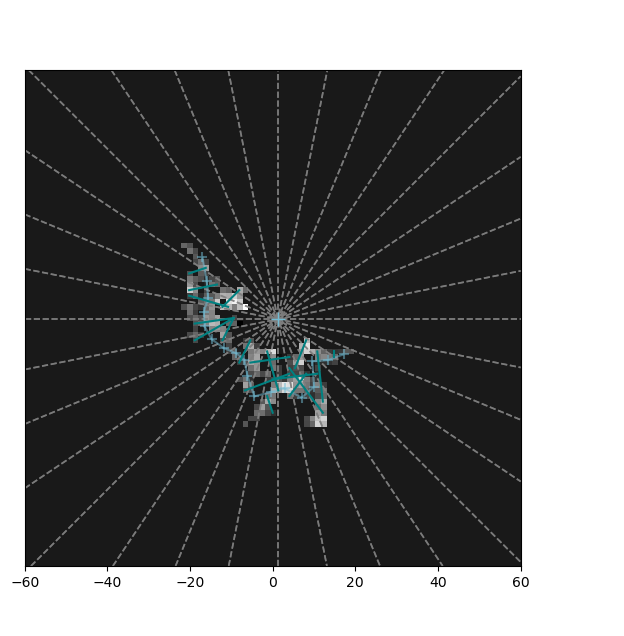

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.41817919491316
13 Width: 13.55039409589333. Distance: 3.846654438321039
14 Width: 10.870459885346364. Distance: 3.5167790747027174
15 Width: 12.209508051421237. Distance: 3.5295732538102498
16 Width: 10.870459885346362. Distance: 3.605108982900894
17 Width: 6.029846231460107. Distance: 3.6619699069810463
18 Width: 0.0. Distance: 3.3258795575134594
19 Width: 6.02984623146011. Distance: 2.596335531521245
20 Width: 10.78651685393259. Distance: 4.384460621999741
21 Width: 11.520005049866343. Distance: 4.968871990088139
22 Width: 4.263745159777586. Distance: 4.0716930412761885
23 Width: 7.260896369170119. Distance: 3

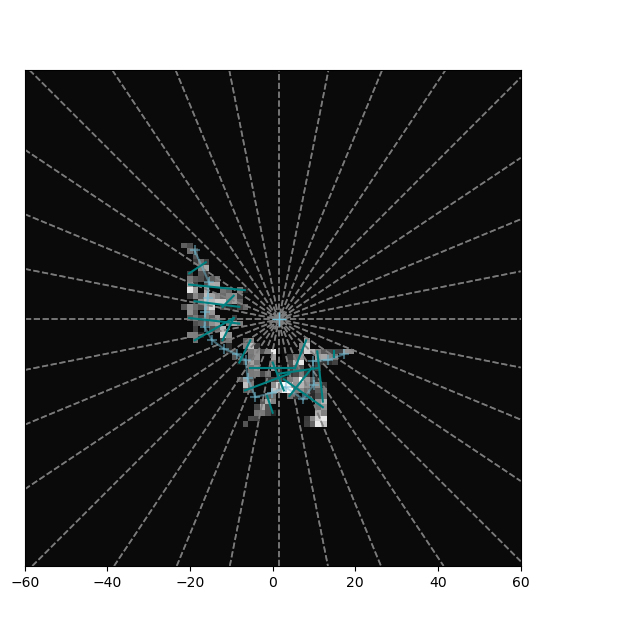

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.374176926722245
13 Width: 12.209508051421237. Distance: 3.8120043502822423
14 Width: 9.815878502400697. Distance: 3.4874930392456442
15 Width: 12.209508051421237. Distance: 3.514348435943135
16 Width: 10.870459885346362. Distance: 3.651048274350904
17 Width: 6.029846231460107. Distance: 3.5951691006763897
18 Width: 0.0. Distance: 3.254732148686107
19 Width: 6.0298462314601. Distance: 2.541650170411384
20 Width: 9.534024015998398. Distance: 3.735167137049359
21 Width: 11.520005049866343. Distance: 5.230502430034534
22 Width: 4.263745159777586. Distance: 4.04294234968315
23 Width: 9.8158785024007. Distance: 3.49643

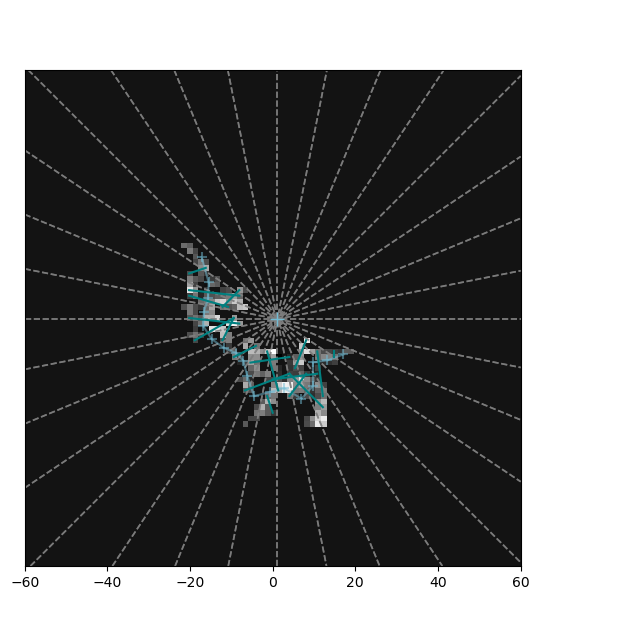

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.424639727663987
13 Width: 13.55039409589333. Distance: 3.844174671324334
14 Width: 6.029846231460107. Distance: 3.671555046428665
15 Width: 9.534024015998398. Distance: 3.6641219589804264
16 Width: 10.870459885346362. Distance: 3.5935735905904056
17 Width: 6.029846231460107. Distance: 3.651850006428384
18 Width: 0.0. Distance: 3.3135230027122384
19 Width: 6.02984623146011. Distance: 2.5798101902377346
20 Width: 10.78651685393259. Distance: 4.377560243332687
21 Width: 11.520005049866343. Distance: 4.964599039970623
22 Width: 4.263745159777586. Distance: 4.056343032358986
23 Width: 7.260896369170119. Distance: 3.6

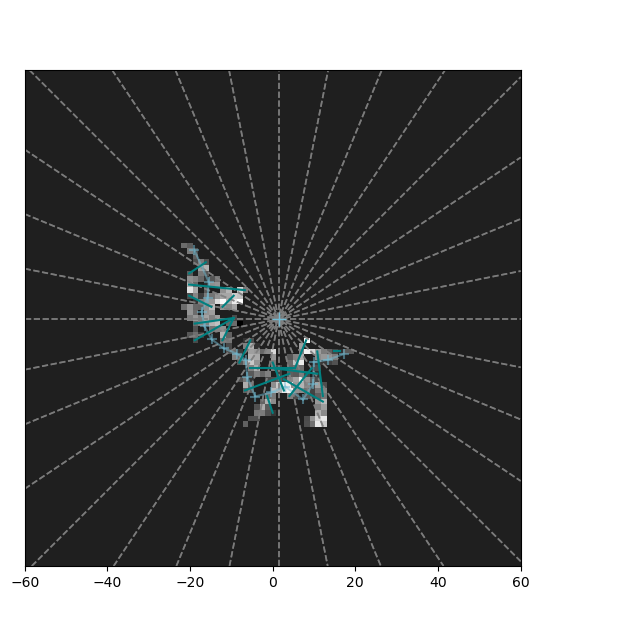

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 5.831995315989833
13 Width: 6.875082490237464. Distance: 4.138828701530289
14 Width: 8.527490319555177. Distance: 3.497274307622633
15 Width: 9.534024015998398. Distance: 3.4990308549774234
16 Width: 10.870459885346362. Distance: 3.5444908528560064
17 Width: 6.029846231460107. Distance: 3.6010707691690484
18 Width: 0.0. Distance: 3.2624977474465178
19 Width: 6.02984623146011. Distance: 2.529525915130576
20 Width: 9.534024015998398. Distance: 3.960390739762285
21 Width: 11.520005049866343. Distance: 5.234440476659766
22 Width: 4.263745159777586. Distance: 4.054431223728027
23 Width: 4.861417450063813. Distance: 3.50

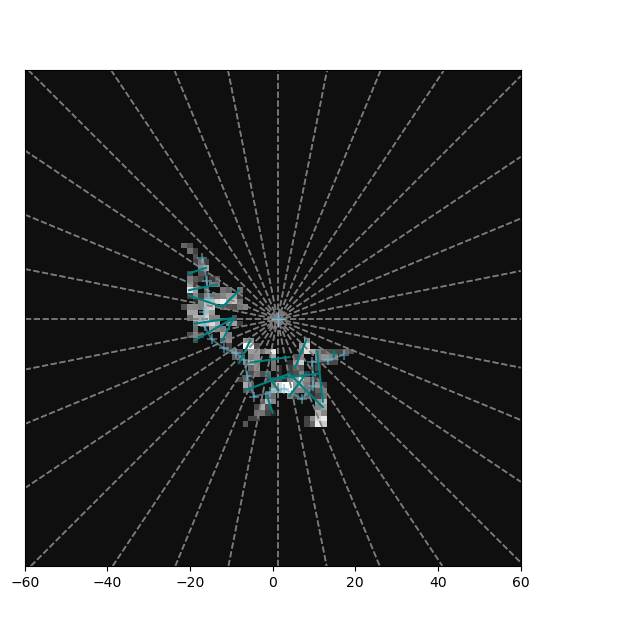

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.374914363847825
13 Width: 13.55039409589333. Distance: 3.7745100869012784
14 Width: 6.875082490237463. Distance: 3.484900336479964
15 Width: 9.534024015998398. Distance: 3.4871874994263083
16 Width: 10.870459885346362. Distance: 3.5331635703949593
17 Width: 6.029846231460107. Distance: 3.5912174515375974
18 Width: 0.0. Distance: 3.25019530676092
19 Width: 6.02984623146011. Distance: 2.512623704651476
20 Width: 9.534024015998398. Distance: 3.9519418371968604
21 Width: 11.118487080317292. Distance: 6.193654665956487
22 Width: 13.881748504701568. Distance: 4.987910823767679
23 Width: 9.534024015998398. Distance: 3.3

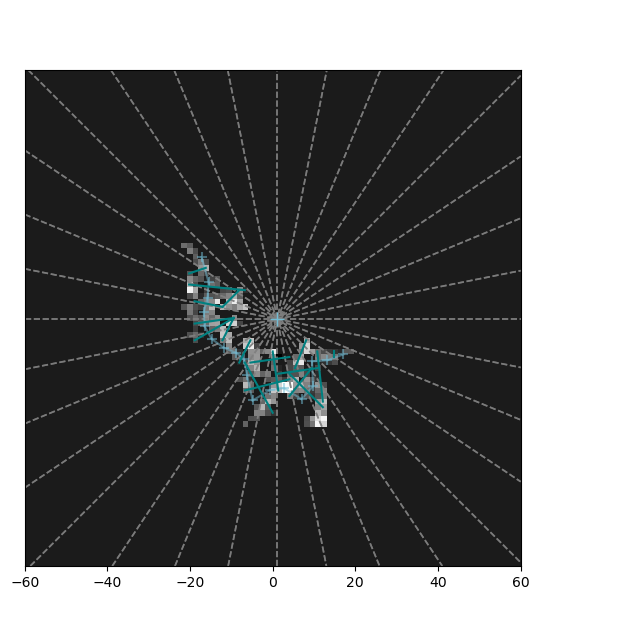

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993565. Distance: 0
12 Width: 4.861417450063805. Distance: 8.431684914506473
13 Width: 13.55039409589333. Distance: 3.8679189439541055
14 Width: 6.875082490237463. Distance: 3.5954541384688135
15 Width: 9.534024015998398. Distance: 3.612127022991884
16 Width: 12.43084645927131. Distance: 3.462098505335523
17 Width: 3.0149231157300567. Distance: 4.008550888503811
18 Width: 0.0. Distance: 3.3428451050812793
19 Width: 6.02984623146011. Distance: 2.6023727864319204
20 Width: 10.78651685393259. Distance: 4.365944002232952
21 Width: 11.520005049866343. Distance: 4.947825905153477
22 Width: 4.263745159777586. Distance: 4.0683154443668945
23 Width: 7.260896369170119. Distance: 3.

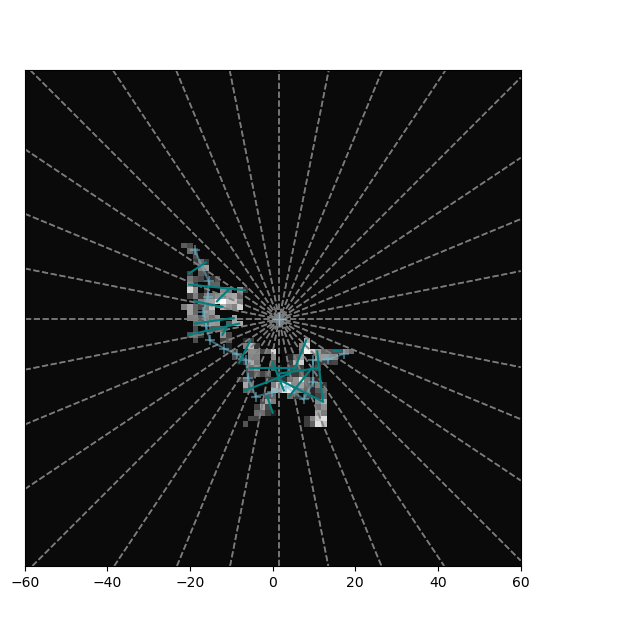

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.372326737242345
13 Width: 12.209508051421237. Distance: 3.786819617997317
14 Width: 9.815878502400697. Distance: 3.483690485729915
15 Width: 9.534024015998398. Distance: 3.4876254997793565
16 Width: 11.520005049866338. Distance: 3.4592155767259336
17 Width: 3.0149231157300567. Distance: 3.920767353883551
18 Width: 0.0. Distance: 3.250672790908662
19 Width: 6.02984623146011. Distance: 2.5153007618270995
20 Width: 9.534024015998398. Distance: 3.9551796462010054
21 Width: 11.118487080317292. Distance: 6.196179856842063
22 Width: 13.881748504701568. Distance: 4.990476607792019
23 Width: 9.8158785024007. Distance: 3.4

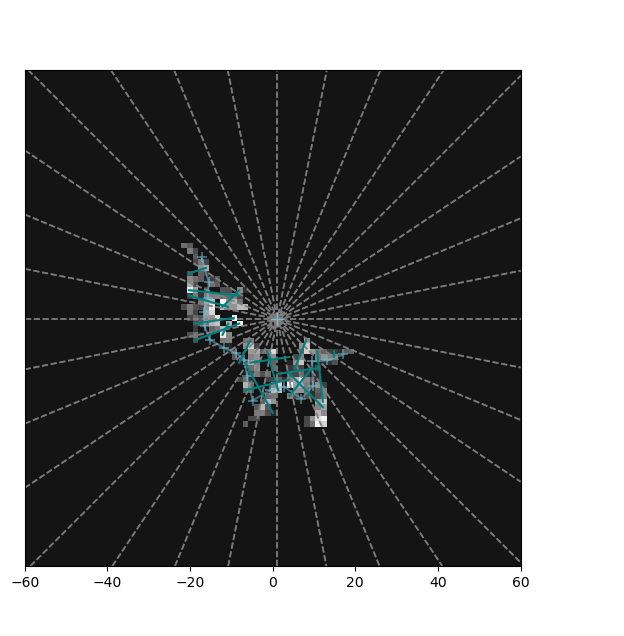

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.376051670122935
13 Width: 12.79123547933277. Distance: 3.679103685023734
14 Width: 10.870459885346364. Distance: 3.5884021416168705
15 Width: 9.534024015998398. Distance: 3.4883139498646316
16 Width: 10.870459885346362. Distance: 3.534302009207259
17 Width: 6.029846231460107. Distance: 3.592540303453533
18 Width: 0.0. Distance: 3.251351342547345
19 Width: 6.02984623146011. Distance: 2.512786524154884
20 Width: 9.534024015998398. Distance: 3.950672930280959
21 Width: 11.118487080317292. Distance: 5.891065477821712
22 Width: 4.263745159777586. Distance: 4.706519036167636
23 Width: 9.534024015998398. Distance: 3.374

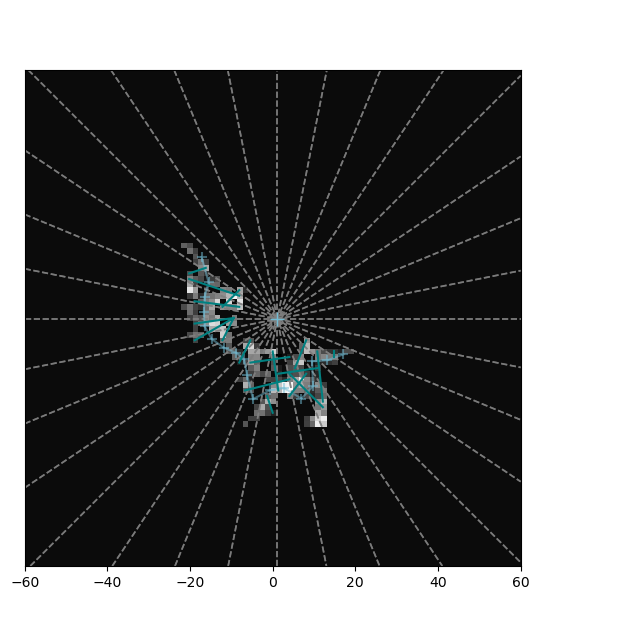

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.418260850526783
13 Width: 13.55039409589333. Distance: 3.77690192669643
14 Width: 12.209508051421237. Distance: 3.5201074150421916
15 Width: 12.209508051421237. Distance: 3.485775391009457
16 Width: 10.870459885346362. Distance: 3.566999952063983
17 Width: 6.029846231460107. Distance: 3.624340496314568
18 Width: 0.0. Distance: 3.285949826113477
19 Width: 6.02984623146011. Distance: 2.545949129630847
20 Width: 9.534024015998398. Distance: 3.95653152838331
21 Width: 11.520005049866343. Distance: 5.463925028348351
22 Width: 4.263745159777586. Distance: 4.229033615981931
23 Width: 9.8158785024007. Distance: 3.512136

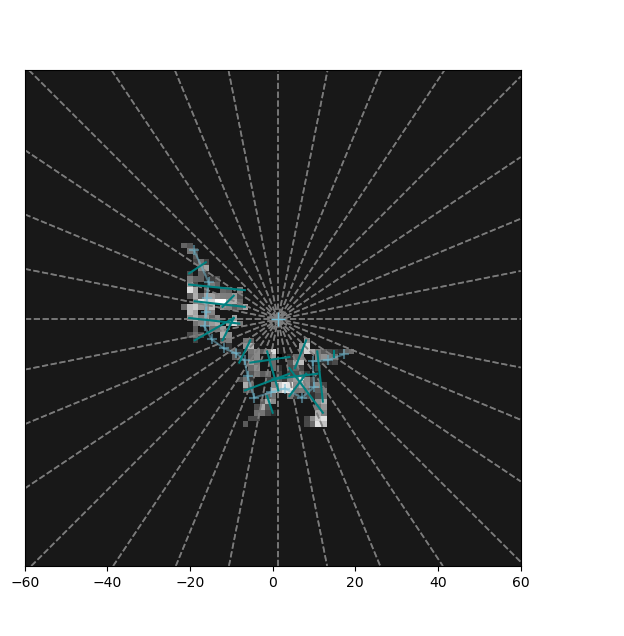

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 5.720414409599043. Distance: 0
12 Width: 4.263745159777589. Distance: 6.3746135415312
13 Width: 12.209508051421237. Distance: 3.809325463208033
14 Width: 9.815878502400697. Distance: 3.4817574227779473
15 Width: 9.534024015998398. Distance: 3.485698666531673
16 Width: 10.870459885346362. Distance: 3.5317022391225197
17 Width: 6.029846231460107. Distance: 3.5897456752064567
18 Width: 0.0. Distance: 3.2486560610542004
19 Width: 6.02984623146011. Distance: 2.5113715829381644
20 Width: 9.534024015998398. Distance: 3.952138369939166
21 Width: 11.118487080317292. Distance: 6.008190416520437
22 Width: 3.0149231157300567. Distance: 4.693927699691054
23 Width: 9.8158785024007. Distance: 3.425

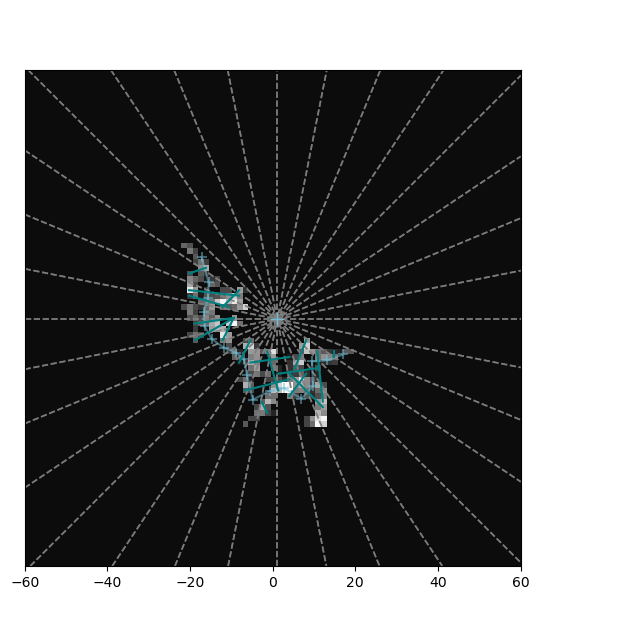

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11 Width: 3.8136096063993614. Distance: 0
12 Width: 4.861417450063805. Distance: 8.424176726860706
13 Width: 12.43084645927131. Distance: 3.763634390496775
14 Width: 6.875082490237463. Distance: 3.6517917697578155
15 Width: 5.55924354015865. Distance: 3.6542431854811004
16 Width: 6.741573033707868. Distance: 3.8200912222906873
17 Width: 4.861417450063805. Distance: 3.6544829067421456
18 Width: 0.0. Distance: 3.3164341401918134
19 Width: 6.02984623146011. Distance: 2.5829092516384233
20 Width: 10.78651685393259. Distance: 4.377849362935937
21 Width: 11.520005049866343. Distance: 4.964318026811517
22 Width: 4.263745159777586. Distance: 4.058795155492127
23 Width: 7.260896369170119. Distance: 3.6

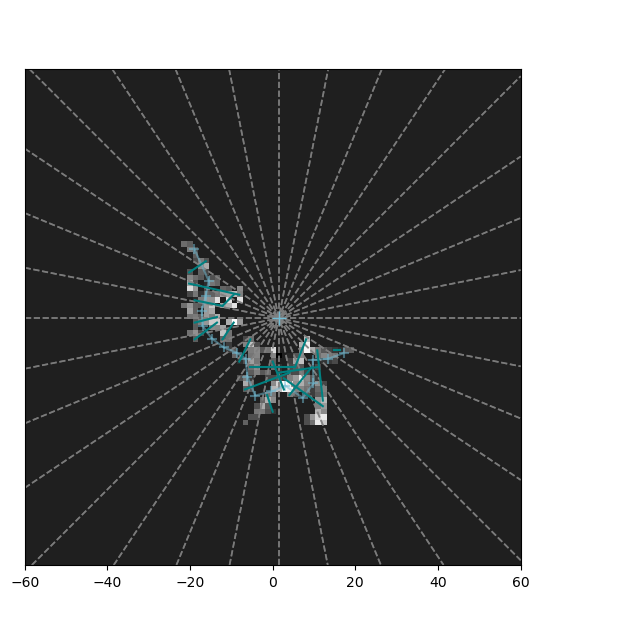

In [21]:
current_rotation = 0

for file in sorted(segmented_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        # load the matched-filter detection output fits file
        hdul = fits.open(f'{mf_catalogs_path}/mf_{galaxy_name}_d={d}_a={a}_pix=8000.fits')
        image_data = np.squeeze(hdul[0].data)

        # extract the area_of_interest
        image_data[~area_of_interest[current_rotation, :, :]] = 0
        
        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)
        
        # plot the bins (only for visual help)
        max_length = 89
        n_bins = 32  
        angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        for angle in angles:
            if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
                ax.axvline(x=x_center, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            else:
                slope = np.tan(angle)
                ax.axline(
                    (x_center, y_center), 
                    slope=slope, 
                    color='gray', 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.8
                )
        
        ax.plot(x_center, y_center, color='#72BCD4', marker='+', markersize=10, label='Center')
        
        # identify outliers
        outliers = find_large_outliers(np.unique(image_data))
        outlier_mask = np.isin(image_data, outliers)
        image_data[outlier_mask] = 0
        
        # identify coordinates of interest
        x_of_interest = []
        y_of_interest = []
        val_of_interest = []
        
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if ~(val == 0):
                    val_of_interest.append(val)
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)
        
        # number of pixels of interest
        n_of_interest = len(x_of_interest)
        
        # calculate the average readius of each bin
        avg_radii, bin_size = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        # plot points for the average radius at the angular midpoint of each bin
        angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
        angles = (angles + bin_size / 2)
        
        x_ang = avg_radii * np.cos(angles) + x_center
        y_ang = -avg_radii * np.sin(angles) + y_center
        
        cmap = plt.cm.gray.copy() # brighter areas represent higher star density
        cmap.set_bad(color='black')
        
        # set value scale AFTER the center is removed
        min_obj = np.min(image_data)
        max_obj = np.max(image_data)
        
        plt.scatter(x_ang, y_ang, color='#72BCD4', marker='+', s=50, alpha=0.5)
        
        # calculate stream length
        total_dist = length_calc(n_bins, x_center, y_center, x_ang, y_ang)
        
        # calculate stream width
        stream_width_counter, stream_width_total = width_calc(image_data, n_bins, x_ang, y_ang)
        
        # calculate average stream width
        if stream_width_counter != 0:
            avg_width = stream_width_total/stream_width_counter
            ratio = total_dist/avg_width
        else:
            avg_width = np.nan
            ratio = np.nan
        print(f"Average Width: {avg_width}")
        print(f"Total Distance: {total_dist}")
        print(f"Length/Width Ratio: {ratio}")
        
        # plot the image with lengths and widths
        current_cmap = copy.copy(mpl.colormaps['gray'])
        current_cmap.set_bad(color='black')
        
        plt.imshow(image_data, extent=[-60,60,-60,60], cmap = current_cmap)
        
        length_array.append(total_dist)
        width_array.append(avg_width)
        ratio_array.append(ratio)
        
        cbar = plt.colorbar(orientation='vertical')
        if cbar.solids is not None:
            cbar.solids.set_alpha(0)
        if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
            for line in cbar.lines:
                line.set_alpha(0)
        cbar.outline.set_alpha(0)
        cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))
        #cbar.set_label('Stellar Density Level', rotation=270, labelpad=15)
        
        plt.gca().xaxis.set_visible(True)
        plt.gca().yaxis.set_visible(False)
        
        ax.invert_yaxis()
        stfit_path = path(f'stfit_outputs/{galaxy_name}/fitted/stfit_{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        stfit_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f'{stfit_path}', dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        hdul.close()
        
        current_orientation = current_orientation + 1

In [15]:
def fibonacci_angler(n):
    """ Calculates n equally-spaced angles around a sphere.

    Args:
        n (int):
            The desired number of angles.

    Returns:
        declination_array (array of floats):
            The declinations of the calculated angles.
        azimuthal_array (array of floats):
            The azimuthals of the calculated angles.
    """
    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    return declination_array, azimuthal_array

declination_array, azimuthal_array = fibonacci_angler(numangles)

In [16]:
def func_fit(theta, length, width):
    """ Ratio as a function of length and width, assuming that the stream is cylindrical.

    Args:
        theta ((array of) float(s)):
            Angle(s) of observation (either declination or azimuthal).
        length ((array of) float(s)):
            Length(s) of the stream.
        width ((array of) float(s)):
            Width(s) of the stream.

    Returns:
        ratio ((array of) float(s)):
            The length-to-width ratio(s) of the stream.
    """

    ratio = (length * np.cos(theta * np.pi / 180) + width * np.sin(theta * np.pi / 180)) / width
    
    return ratio

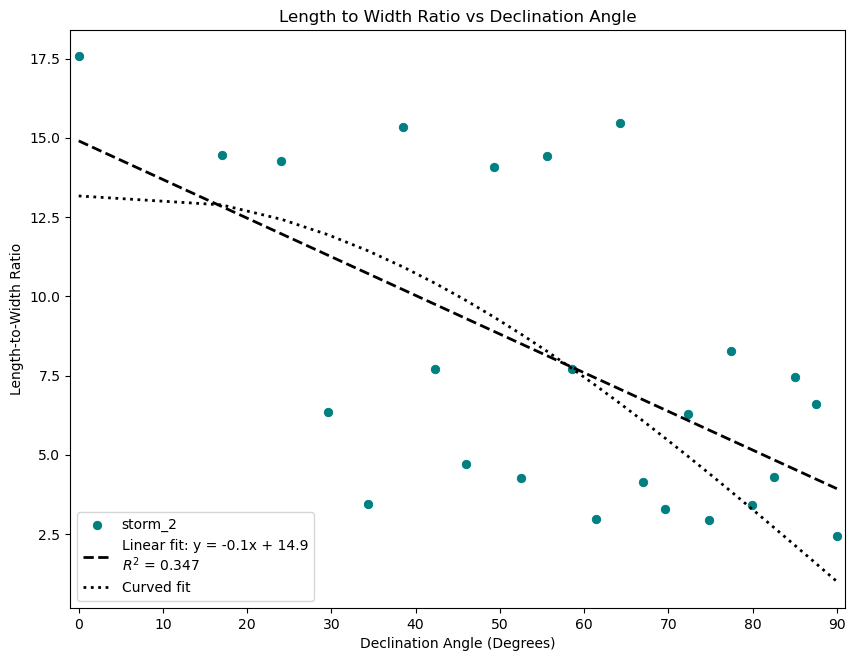

y= -0.12196048620841146 x + 14.90515379601293 , R^2= 0.3469634640464506


In [17]:
# Plot and save the length-to-width ratio vs. declination graph with a linear and a curved fit

x = declination_array * 180 / (np.pi)
y = ratio_array

p0 = np.array([22,1])
popt, pcov = curve_fit(func_fit, x, y, p0)
our_plot = func_fit(x, popt[0], popt[1])

m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

r_matrix = np.corrcoef(x, y)
r_value = r_matrix[0, 1]
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.scatter(x, y, color='teal', linewidth=0.7, label=f'{galaxy_name}')
ax.plot(x, y_pred, color='black', linestyle='--', linewidth=2, \
        label=f'Linear fit: y = {m:.1f}x + {b:.1f}\n$R^2$ = {r_squared:.3f}')
ax.plot(x, our_plot, color='black', linestyle=':', linewidth=2, \
        label=f'Curved fit')
ax.set_xlim(left=-1, right=91)

ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

ax.set_xlabel("Declination Angle (Degrees)")
ax.set_ylabel("Length-to-Width Ratio")
ax.set_title("Length to Width Ratio vs Declination Angle")

ax.legend()

ratio_v_angle_path=path(f'stfit_outputs/{galaxy_name}')
ratio_v_angle_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(f'{ratio_v_angle_path}/lw_vs_dec.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('y=', m, 'x +', b, ', R^2=', r_squared)

In [18]:
# Define the path to save the length, width and their ratio for every angle
lw_path=path(f'stfit_outputs/{galaxy_name}/lw.txt')
lw_path.parent.mkdir(parents=True, exist_ok=True)

In [19]:
# Save the length, width and their ratio for every angle
if os.path.exists(lw_path):
    os.remove(lw_path)

for i in range(len(ratio_array)):
    with open(f'{lw_path}', 'a') as file:   
        file.write('center of ' f'{galaxy_name}' ' at d=' f'{x[i]:.1f}' ': length=' f'{length_array[i]}' ', width=' f'{width_array[i]}' ', length-to-width ratio=' f'{ratio_array[i]}' '\n')